In [ ]:
import numpy as np

def activation_func(val):
    return 1 if val >= 0 else 0

def train_logic(inputs, targets, rate=0.1, cycles=10):
    features = inputs.shape[1]
    coeffs = np.zeros(features)
    offset = 0

    for i in range(cycles):
        for data, answer in zip(inputs, targets):
            total = np.dot(coeffs, data) + offset
            result = activation_func(total)

            diff = answer - result
            coeffs += rate * diff * data
            offset += rate * diff

    return coeffs, offset

def test_logic(inputs, coeffs, offset):
    outputs = []
    for data in inputs:
        total = np.dot(coeffs, data) + offset
        result = activation_func(total)
        outputs.append(result)
    return outputs

or_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
or_outputs = np.array([0, 1, 1, 1])

and_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
and_outputs = np.array([0, 0, 0, 1])

print("\nLearning OR Logic:")
or_weights, or_bias = train_logic(or_inputs, or_outputs)
print("\nChecking OR Logic:")
print("Results:", test_logic(or_inputs, or_weights, or_bias))

print("\nLearning AND Logic:")
and_weights, and_bias = train_logic(and_inputs, and_outputs)
print("\nChecking AND Logic:")
print("Results:", test_logic(and_inputs, and_weights, and_bias))



Learning OR Logic:

Checking OR Logic:
Results: [0, 1, 1, 1]

Learning AND Logic:

Checking AND Logic:
Results: [0, 0, 0, 1]


   race_id  horse_id  1-101  1-102  1-103  1-104  1-105  1-106  1-107  1-108  \
0   495886    565129    NaN    NaN    NaN    NaN    NaN    NaN    NaN  -0.71   
1   495886    607093    NaN    NaN    NaN    NaN    NaN    NaN    NaN  -0.05   
2   495886    637337    NaN    NaN    NaN    NaN    NaN    NaN    NaN  -0.97   
3   495886    659819    NaN    NaN    NaN    NaN    NaN    NaN    NaN   0.21   
4   495886    661530    NaN    NaN    NaN    NaN    NaN    NaN    NaN   0.08   

   ...  3-132  4-105  4-109  4-110  4-114  4-115  4-116  4-117  calc_position  \
0  ...  -1.16    0.0   1.87   1.87  -2.07  -1.96  -1.95  -0.30            8.0   
1  ...   0.77    0.0   0.00   0.00   0.00   0.00   0.00   0.07            5.0   
2  ...  -1.16    0.0   0.00   0.00   0.48   0.44   0.39  -0.86            7.0   
3  ...   0.77    0.0   0.00   0.00   0.32   1.09   0.78  -0.86            1.0   
4  ...   0.77    0.0   0.00   0.00   0.00   0.00   0.39   1.17            4.0   

   price  
0   17.0  
1   26.0  

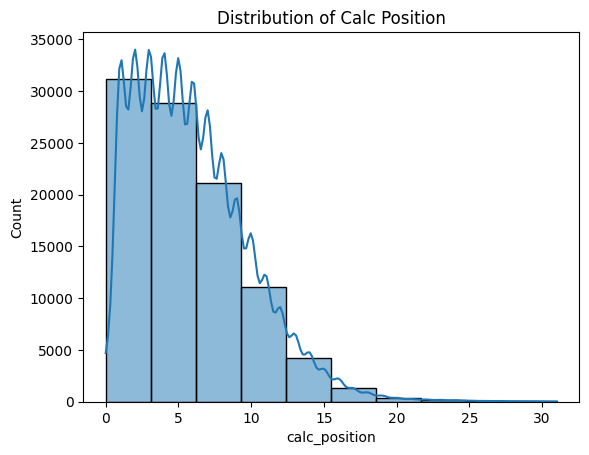

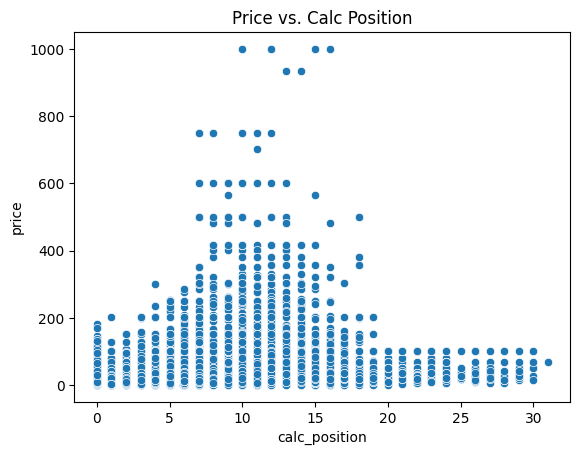

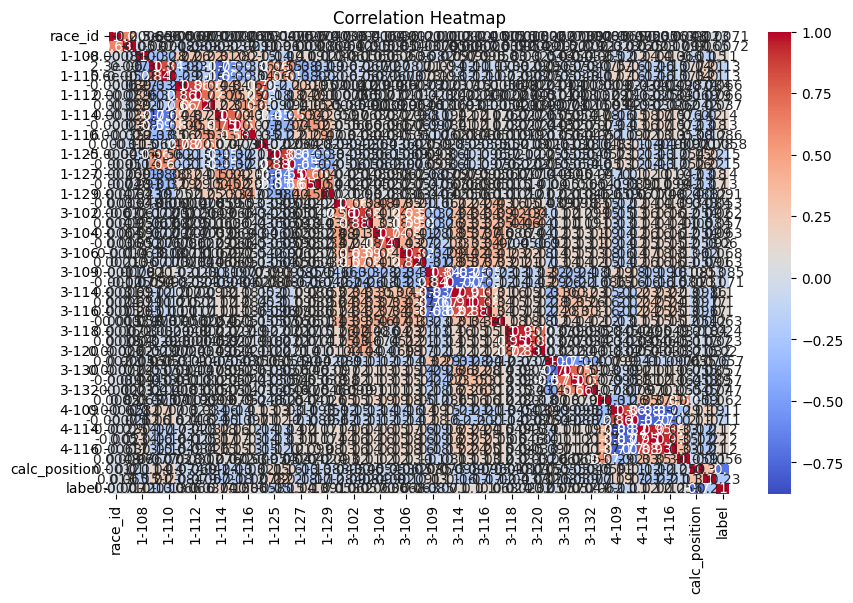


Final Dataset after cleaning:
    1-108  1-109  1-110  1-111  1-112  1-113  1-114  1-115  1-116  1-117  ...  \
0  -0.71   0.78   0.59   1.69   1.78   0.47  -1.28  -1.12  -1.88   2.03  ...   
1  -0.05   0.78   0.59   1.49   1.47   2.34  -0.10  -0.27   0.20   0.85  ...   
2  -0.97   1.60   1.37   0.07   0.10   0.23  -1.10  -0.98  -0.92   0.25  ...   
3   0.21  -0.88  -0.98  -0.34  -0.42  -0.23   0.82   0.22   0.50  -0.56  ...   
4   0.08  -0.05   0.59  -0.34  -0.42   0.00  -0.39  -0.67   0.08  -0.35  ...   

   horse_1760069  horse_1765127  horse_1765129  horse_1770387  horse_1770388  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4          False          False          False          False          False   

   hor

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("horseRacing.csv")
print(data.head())

threshold = 0.5 * len(data)
data = data.loc[:, data.isnull().sum() < threshold]
data = data.fillna(data.mean())
data = data.drop_duplicates()
print("\nDataset After Cleaning:\n", data.info())

data['label'] = data['calc_position'].apply(lambda x: 1 if x <= 3 else 0)
print("\nLabel Distribution:\n", data['label'].value_counts())

sns.histplot(data['calc_position'], bins=10, kde=True)
plt.title('Distribution of Calc Position')
plt.show()

sns.scatterplot(x='calc_position', y='price', data=data)
plt.title('Price vs. Calc Position')
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


data = pd.get_dummies(data, columns=['race_id'], prefix='race')

data = pd.get_dummies(data, columns=['horse_id'], prefix='horse')

print("\nDataset after cleaning:\n", data.head())

data.to_csv("horseRacing_cleaned.csv", index=False)




print("""
Question 5:
1. The dataset had missing values in some columns.
   - Fix: Columns with more than 50% missing values were removed, and the rest were filled with the column's mean value.

2. There were duplicate rows.
   - Fix: Removed duplicate rows.

3. The dataset lacked a binary label column for classification.
   - Fix: Created a 'label' column based on 'calc_position'. Positions 1-3 were marked as 1 (win), and others as 0 (loss).

4. The 'race_id' and 'horse_id' columns were categorical and needed encoding for analysis.
   - Fix: Applied one-hot encoding to these columns.

""")




Cleaned Dataset Loaded Successfully!

Confusion Matrix:
 [[70  0]
 [31  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.69      1.00      0.82        70
           1       0.00      0.00      0.00        31

    accuracy                           0.69       101
   macro avg       0.35      0.50      0.41       101
weighted avg       0.48      0.69      0.57       101



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


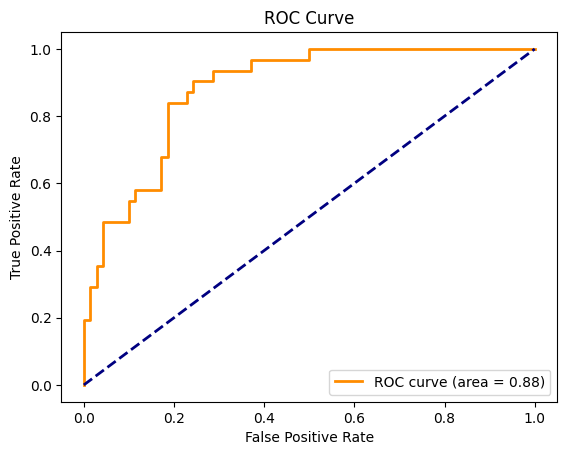

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

print("Cleaned Dataset Loaded Successfully!")

X = data.drop(columns=['label']).select_dtypes(include=['number']).values
y = data['label'].values.reshape(-1, 1)

mean = X.mean(axis=0)
std = X.std(axis=0)
std[std == 0] = 1
X = (X - mean) / std

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    return sigmoid(z) * (1 - sigmoid(z))

def initialize_weights(input_dim, hidden_dim, output_dim):
    np.random.seed(42)
    W1 = np.random.randn(input_dim, hidden_dim) * 0.01
    b1 = np.zeros((1, hidden_dim))
    W2 = np.random.randn(hidden_dim, output_dim) * 0.01
    b2 = np.zeros((1, output_dim))
    return W1, b1, W2, b2

def forward_propagation(X, W1, b1, W2, b2):
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)
    cache = (Z1, A1, Z2, A2)
    return A2, cache

def backward_propagation(X, y, cache, W1, W2):
    Z1, A1, Z2, A2 = cache
    m = X.shape[0]

    dZ2 = A2 - y
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dZ1 = np.dot(dZ2, W2.T) * sigmoid_derivative(Z1)
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

def train_mlp(X, y, hidden_dim, learning_rate, epochs):
    input_dim = X.shape[1]
    output_dim = 1

    W1, b1, W2, b2 = initialize_weights(input_dim, hidden_dim, output_dim)

    losses = []
    for epoch in range(epochs):
        A2, cache = forward_propagation(X, W1, b1, W2, b2)

        loss = -np.mean(y * np.log(A2) + (1 - y) * np.log(1 - A2))
        losses.append(loss)

        dW1, db1, dW2, db2 = backward_propagation(X, y, cache, W1, W2)

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2



    return W1, b1, W2, b2

hidden_dim = 10
learning_rate = 0.01
epochs = 1000
W1, b1, W2, b2 = train_mlp(X_train, y_train, hidden_dim, learning_rate, epochs)


def predict(X, W1, b1, W2, b2):
    A2, _ = forward_propagation(X, W1, b1, W2, b2)
    return (A2 > 0.5).astype(int)

y_pred = predict(X_test, W1, b1, W2, b2)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

cr = classification_report(y_test, y_pred)
print("\nClassification Report:\n", cr)

y_pred_prob = forward_propagation(X_test, W1, b1, W2, b2)[0]
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()
